In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from __future__ import annotations

import argparse
from collections.abc import Iterable
from dataclasses import dataclass
from pathlib import Path

In [2]:
def load_h5(filepath: str | Path, filename: str) -> dict[str, np.ndarray]:
    """
    Load all datasets from an HDF5 file.

    Parameters
    ----------
    filepath
        Directory containing the HDF5 file.

    filename
        Name of the HDF5 file, including the .h5 extension.

    Returns
    -------
    dict[str, np.ndarray]
        Dictionary containing all HDF5 datasets.

        The dictionary keys are the full dataset paths inside the
        HDF5 file. The values are NumPy arrays.

    Raises
    ------
    FileNotFoundError
        If the requested HDF5 file does not exist.

    OSError
        If the file exists but cannot be opened as an HDF5 file.
    """
    full_path = Path(filepath) / filename

    if not full_path.is_file():
        raise FileNotFoundError(
            f"HDF5 file was not found: {full_path.resolve()}"
        )

    data: dict[str, np.ndarray] = {}

    with h5py.File(full_path, mode="r") as h5_file:

        def load_dataset(name: str, obj: h5py.Dataset | h5py.Group) -> None:
            if isinstance(obj, h5py.Dataset):
                data[name] = obj[...]

        h5_file.visititems(load_dataset)

    return data

In [3]:
case_dir = Path("/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/BasC/param_space/Re010_Ca0_010_theta45")

filename = f"thinfilm_closure_data.h5"

closure_data = load_h5(case_dir, filename)

print("Snapshot datasets:")
for key, value in closure_data.items():
    print(f"  {key:<35} shape={value.shape}, dtype={value.dtype}")

Snapshot datasets:
  dt                                  shape=(103,), dtype=float64
  h                                   shape=(16384, 103), dtype=float64
  h_m                                 shape=(16384, 103), dtype=float64
  h_x                                 shape=(16384, 103), dtype=float64
  h_xx                                shape=(16384, 103), dtype=float64
  parameters/Ca                       shape=(), dtype=float64
  parameters/Re                       shape=(), dtype=float64
  parameters/angle                    shape=(), dtype=float64
  parameters/h0                       shape=(), dtype=float64
  parameters/mu_ratio                 shape=(), dtype=float64
  parameters/rho_ratio                shape=(), dtype=float64
  parameters/t0                       shape=(), dtype=float64
  parameters/u0                       shape=(), dtype=float64
  q                                   shape=(16384, 103), dtype=float64
  q_m                                 shape=(16384, 103), d

In [4]:
def first_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the first derivative with respect to x for a field
    stored as (nx, nt).

    Fourth-order central differences are used in the interior.
    Fourth-order one-sided differences are used near the boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        Uniformly spaced x coordinates.

    field : ndarray, shape (nx, nt)
        Field values. The first axis must correspond to x.

        Examples:
            h
            q
            tau_wall
            shape_factor

    Returns
    -------
    dfield_dx : ndarray, shape (nx, nt)
        Fourth-order approximation to df/dx at every time.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if x.ndim != 1:
        raise ValueError(
            "x must be a one-dimensional array."
        )

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field.shape[0] != x.size:
        raise ValueError(
            "The first dimension of field must equal len(x). "
            f"Received field.shape={field.shape}, "
            f"len(x)={x.size}."
        )

    if x.size < 5:
        raise ValueError(
            "At least five x points are required for "
            "fourth-order differentiation."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid must be uniformly spaced."
        )

    dfield_dx = np.empty_like(field, dtype=float)

    # --------------------------------------------------------
    # Interior
    # Fourth-order central difference
    # --------------------------------------------------------

    dfield_dx[2:-2, :] = (
        field[:-4, :]
        - 8.0 * field[1:-3, :]
        + 8.0 * field[3:-1, :]
        - field[4:, :]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Left boundary
    # --------------------------------------------------------

    dfield_dx[0, :] = (
        -25.0 * field[0, :]
        + 48.0 * field[1, :]
        - 36.0 * field[2, :]
        + 16.0 * field[3, :]
        - 3.0 * field[4, :]
    ) / (12.0 * dx)

    dfield_dx[1, :] = (
        -3.0 * field[0, :]
        - 10.0 * field[1, :]
        + 18.0 * field[2, :]
        - 6.0 * field[3, :]
        + field[4, :]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Right boundary
    # --------------------------------------------------------

    dfield_dx[-2, :] = (
        -field[-5, :]
        + 6.0 * field[-4, :]
        - 18.0 * field[-3, :]
        + 10.0 * field[-2, :]
        + 3.0 * field[-1, :]
    ) / (12.0 * dx)

    dfield_dx[-1, :] = (
        3.0 * field[-5, :]
        - 16.0 * field[-4, :]
        + 36.0 * field[-3, :]
        - 48.0 * field[-2, :]
        + 25.0 * field[-1, :]
    ) / (12.0 * dx)

    return dfield_dx

In [5]:
def second_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the second derivative with respect to x for a field
    stored as (nx, nt).

    Fourth-order central differences are used in the interior.
    Fourth-order one-sided differences are used near boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        Uniformly spaced x coordinates.

    field : ndarray, shape (nx, nt)
        Field values. The first axis corresponds to x.

    Returns
    -------
    d2field_dx2 : ndarray, shape (nx, nt)
        Fourth-order approximation to d²f/dx².
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if x.ndim != 1:
        raise ValueError(
            "x must be one-dimensional."
        )

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field.shape[0] != x.size:
        raise ValueError(
            "The first dimension of field must equal len(x). "
            f"Received field.shape={field.shape}, "
            f"len(x)={x.size}."
        )

    if x.size < 6:
        raise ValueError(
            "At least six x points are required."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid must be uniformly spaced."
        )

    d2field_dx2 = np.empty_like(
        field,
        dtype=float,
    )

    # --------------------------------------------------------
    # Interior
    # --------------------------------------------------------

    d2field_dx2[2:-2, :] = (
        -field[4:, :]
        + 16.0 * field[3:-1, :]
        - 30.0 * field[2:-2, :]
        + 16.0 * field[1:-3, :]
        - field[:-4, :]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Left boundary
    # --------------------------------------------------------

    d2field_dx2[0, :] = (
        45.0 * field[0, :]
        - 154.0 * field[1, :]
        + 214.0 * field[2, :]
        - 156.0 * field[3, :]
        + 61.0 * field[4, :]
        - 10.0 * field[5, :]
    ) / (12.0 * dx**2)

    d2field_dx2[1, :] = (
        10.0 * field[0, :]
        - 15.0 * field[1, :]
        - 4.0 * field[2, :]
        + 14.0 * field[3, :]
        - 6.0 * field[4, :]
        + field[5, :]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Right boundary
    # --------------------------------------------------------

    d2field_dx2[-2, :] = (
        field[-6, :]
        - 6.0 * field[-5, :]
        + 14.0 * field[-4, :]
        - 4.0 * field[-3, :]
        - 15.0 * field[-2, :]
        + 10.0 * field[-1, :]
    ) / (12.0 * dx**2)

    d2field_dx2[-1, :] = (
        -10.0 * field[-6, :]
        + 61.0 * field[-5, :]
        - 156.0 * field[-4, :]
        + 214.0 * field[-3, :]
        - 154.0 * field[-2, :]
        + 45.0 * field[-1, :]
    ) / (12.0 * dx**2)

    return d2field_dx2

In [6]:
def first_derivative_t(
    field: np.ndarray,
    field_minus: np.ndarray,
    time: np.ndarray,
    time_minus: np.ndarray,
) -> np.ndarray:
    """
    Compute first-order backward time derivatives for a field
    stored as (nx, nt).

    Each current snapshot has a corresponding previous snapshot:

        df/dt[:, j] =
            (field[:, j] - field_minus[:, j])
            / (time[j] - time_minus[j])

    Parameters
    ----------
    field : ndarray, shape (nx, nt)
        Quantity at the current snapshot times.

    field_minus : ndarray, shape (nx, nt)
        Same quantity at the corresponding previous times.

    time : ndarray, shape (nt,)
        Current snapshot times.

    time_minus : ndarray, shape (nt,)
        Previous snapshot times.

    Returns
    -------
    dfield_dt : ndarray, shape (nx, nt)
        First-order approximation to df/dt.
    """

    field = np.asarray(field, dtype=float)
    field_minus = np.asarray(field_minus, dtype=float)

    time = np.asarray(time, dtype=float)
    time_minus = np.asarray(time_minus, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field_minus.ndim != 2:
        raise ValueError(
            "field_minus must have shape (nx, nt)."
        )

    if field.shape != field_minus.shape:
        raise ValueError(
            "field and field_minus must have identical shapes. "
            f"Received {field.shape} and {field_minus.shape}."
        )

    if time.ndim != 1 or time_minus.ndim != 1:
        raise ValueError(
            "time and time_minus must be one-dimensional."
        )

    if time.shape != time_minus.shape:
        raise ValueError(
            "time and time_minus must have identical shapes."
        )

    if field.shape[1] != time.size:
        raise ValueError(
            "The second dimension of field must match "
            "the number of time values. "
            f"Received field.shape={field.shape}, "
            f"time.size={time.size}."
        )

    dt = time - time_minus

    if np.any(dt <= 0.0):
        bad_indices = np.where(dt <= 0.0)[0]

        raise ValueError(
            "All time values must be greater than their "
            "corresponding time_minus values. "
            f"Bad indices: {bad_indices[:10]}"
        )

    # dt has shape (nt,)
    #
    # field has shape (nx, nt)
    #
    # NumPy broadcasts dt across the x dimension.

    dfield_dt = (
        field - field_minus
    ) / dt[np.newaxis, :]

    return dfield_dt

Baseline spatial correlation maps
1. Heatmaps for closure terms against spatial variables
2. Correlations at t and t-dt

In [7]:
# ------------------------------------------------------------
# Load fields
# ------------------------------------------------------------

t = closure_data["t"]
tm = closure_data["tm"]

x = closure_data["x"]

h = closure_data["h"]
q = closure_data["q"]

hm = closure_data["h_m"]
qm = closure_data["q_m"]

h_x = first_derivative_x(x, h)
h_xx = second_derivative_x(x, h)
hm_x = first_derivative_x(x, hm)
hm_xx = second_derivative_x(x, hm)

q_x = first_derivative_x(x, q)
q_xx = second_derivative_x(x, q)
qm_x = first_derivative_x(x, qm)
qm_xx = second_derivative_x(x, qm)

h_t = first_derivative_t(h, hm, t, tm)
q_t = first_derivative_t(q, qm, t, tm)

phi_sf = closure_data["shape_factor"]
tau_w = closure_data["tau_wall"]

phi_sf_m = closure_data["shape_factor"]
tau_w_m = closure_data["tau_wall"]

Requested time : 200.000000
Closest time   : 200.000000
Time index     : 19


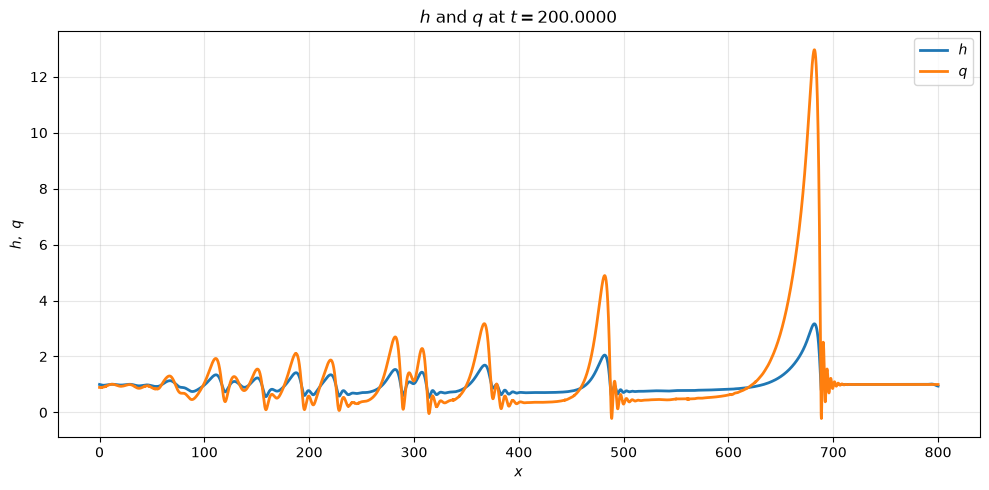

In [8]:
time_to_plot = 200.0   # Change this to the desired time

# Find snapshot closest to requested time
time_index = np.argmin(np.abs(t - time_to_plot))

actual_time = t[time_index]

print(f"Requested time : {time_to_plot:.6f}")
print(f"Closest time   : {actual_time:.6f}")
print(f"Time index     : {time_index}")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    x,
    h[:, time_index],
    label=r"$h$",
    linewidth=2,
)

ax.plot(
    x,
    q[:, time_index],
    label=r"$q$",
    linewidth=2,
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$h,\ q$")
ax.set_title(
    rf"$h$ and $q$ at $t={actual_time:.4f}$"
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
t_start = 200
time_index = np.argmin(np.abs(t - t_start))

t = t[time_index:]
tm = tm[time_index:]


h = h[:, time_index:]
q = q[:, time_index:]


hm = hm[:, time_index:]
qm = qm[:, time_index:]


h_x = h_x[:, time_index:]
h_xx = h_xx[:, time_index:]

q_x = q_x[:, time_index:]
q_xx = q_xx[:, time_index:]

hm_x = hm_x[:, time_index:]
hm_xx = hm_xx[:, time_index:]

qm_x = qm_x[:, time_index:]
qm_xx = qm_xx[:, time_index:]


h_t = h_t[:, time_index:]
q_t = q_t[:, time_index:]

phi_sf = phi_sf[:, time_index:]
tau_w = tau_w[:, time_index:]

phi_sf_m = phi_sf_m[:, time_index:]
tau_w_m = tau_w_m[:, time_index:]

In [10]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

def calculate_correlations(x_data, y_data):
    """
    Calculate Pearson and Spearman correlations between two arrays.

    Arrays are flattened before calculating the correlation.
    NaN and infinite pairs are removed.
    """

    x_data = np.asarray(x_data).ravel()
    y_data = np.asarray(y_data).ravel()

    valid = (
        np.isfinite(x_data)
        & np.isfinite(y_data)
    )

    x_valid = x_data[valid]
    y_valid = y_data[valid]

    if x_valid.size < 2:
        return np.nan, np.nan

    # Correlation is undefined for a constant variable
    if (
        np.std(x_valid) == 0.0
        or np.std(y_valid) == 0.0
    ):
        return np.nan, np.nan

    pearson = pearsonr(
        x_valid,
        y_valid,
    ).statistic

    spearman = spearmanr(
        x_valid,
        y_valid,
    ).statistic

    return pearson, spearman

In [11]:
predictors = {
    # Current snapshot
    "h(t)": h,
    "q(t)": q,
    "h_x(t)": h_x,
    "h_xx(t)": h_xx,
    "q_x(t)": q_x,
    "q_xx(t)": q_xx,

    # Previous snapshot
    "h(t-dt)": hm,
    "q(t-dt)": qm,
    "h_x(t-dt)": hm_x,
    "h_xx(t-dt)": hm_xx,
    "q_x(t-dt)": qm_x,
    "q_xx(t-dt)": qm_xx,

    # Temporal information
    "h_t": h_t,
    "q_t": q_t,
}

closures = {
    "Shape factor": phi_sf,
    "Wall shear": tau_w,
}

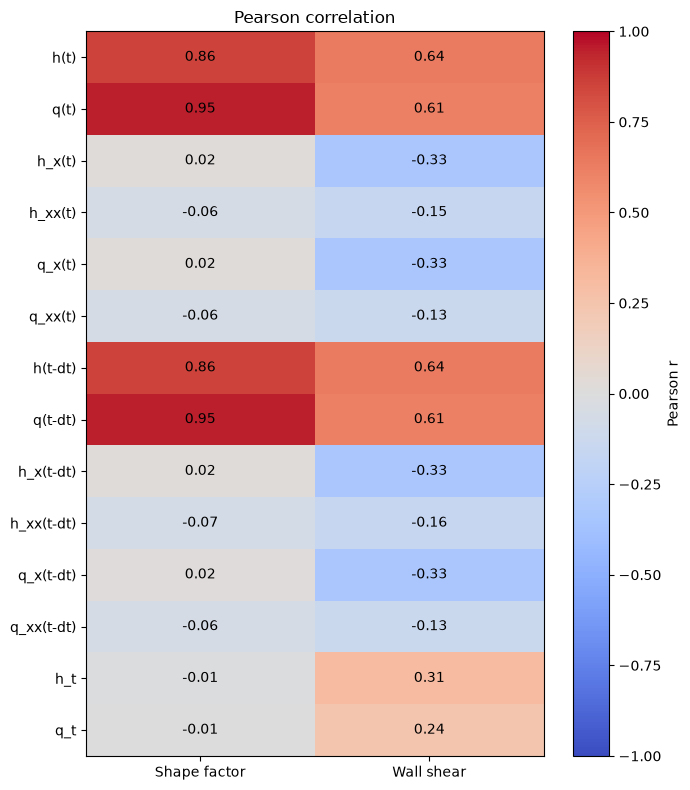

In [12]:
# ------------------------------------------------------------
# Global correlations over all x and t
# ------------------------------------------------------------

pearson_matrix = pd.DataFrame(
    index=predictors.keys(),
    columns=closures.keys(),
    dtype=float,
)

spearman_matrix = pd.DataFrame(
    index=predictors.keys(),
    columns=closures.keys(),
    dtype=float,
)


for predictor_name, predictor_data in predictors.items():

    for closure_name, closure_data_i in closures.items():

        pearson, spearman = calculate_correlations(
            predictor_data,
            closure_data_i,
        )

        pearson_matrix.loc[
            predictor_name,
            closure_name
        ] = pearson

        spearman_matrix.loc[
            predictor_name,
            closure_name
        ] = spearman


# ------------------------------------------------------------
# Pearson heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 8))

im = ax.imshow(
    pearson_matrix.values,
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_xticks(
    np.arange(len(pearson_matrix.columns))
)
ax.set_xticklabels(
    pearson_matrix.columns
)

ax.set_yticks(
    np.arange(len(pearson_matrix.index))
)
ax.set_yticklabels(
    pearson_matrix.index
)

for i in range(len(pearson_matrix.index)):
    for j in range(len(pearson_matrix.columns)):
        ax.text(
            j,
            i,
            f"{pearson_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Pearson correlation")

fig.colorbar(
    im,
    ax=ax,
    label="Pearson r",
)

plt.tight_layout()
plt.show()

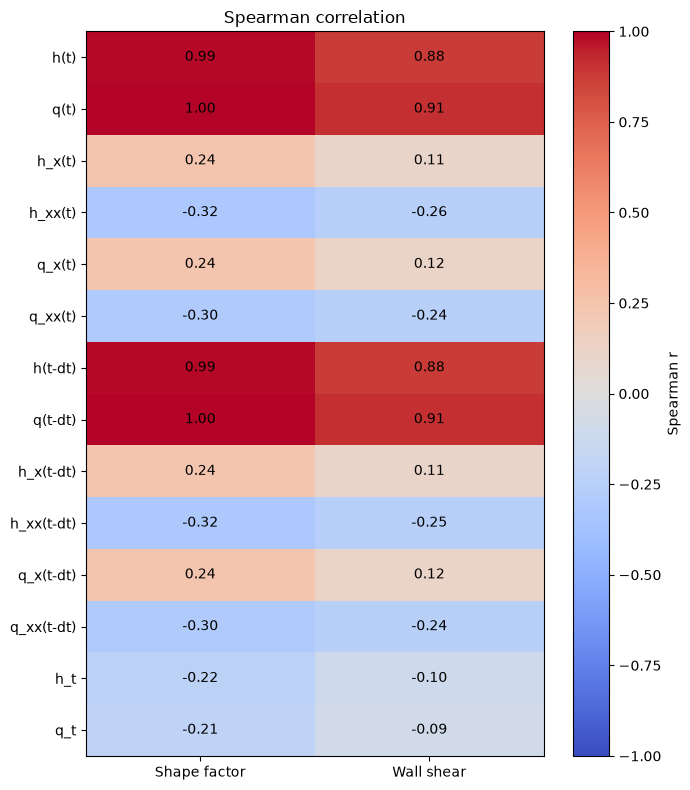

In [13]:
# ------------------------------------------------------------
# Spearman heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 8))

im = ax.imshow(
    spearman_matrix.values,
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_xticks(
    np.arange(len(spearman_matrix.columns))
)
ax.set_xticklabels(
    spearman_matrix.columns
)

ax.set_yticks(
    np.arange(len(spearman_matrix.index))
)
ax.set_yticklabels(
    spearman_matrix.index
)

for i in range(len(spearman_matrix.index)):
    for j in range(len(spearman_matrix.columns)):
        ax.text(
            j,
            i,
            f"{spearman_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Spearman correlation")

fig.colorbar(
    im,
    ax=ax,
    label="Spearman r",
)

plt.tight_layout()
plt.show()

In [14]:
def correlations_vs_time(
    predictor,
    closure,
):
    """
    Calculate spatial Pearson and Spearman correlations
    independently at every sampling time.

    Parameters
    ----------
    predictor : ndarray, shape (nx, nt)
    closure : ndarray, shape (nx, nt)

    Returns
    -------
    pearson_t : ndarray, shape (nt,)
    spearman_t : ndarray, shape (nt,)
    """

    predictor = np.asarray(predictor)
    closure = np.asarray(closure)

    if predictor.shape != closure.shape:
        raise ValueError(
            "predictor and closure must have the same shape."
        )

    nt = predictor.shape[1]

    pearson_t = np.full(nt, np.nan)
    spearman_t = np.full(nt, np.nan)

    for j in range(nt):

        pearson_t[j], spearman_t[j] = (
            calculate_correlations(
                predictor[:, j],
                closure[:, j],
            )
        )

    return pearson_t, spearman_t

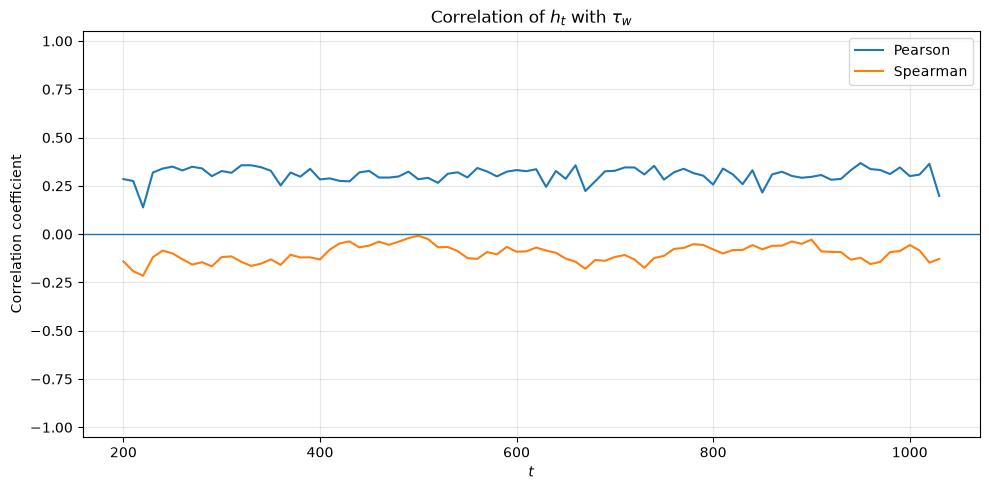

In [15]:
pearson_t, spearman_t = correlations_vs_time(h_t, tau_w,)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t, pearson_t, label="Pearson",)

ax.plot(t, spearman_t, label="Spearman",)

ax.axhline(0.0, linewidth=1,)

ax.set_xlabel(r"$t$")
ax.set_ylabel("Correlation coefficient")

ax.set_ylim(-1.05, 1.05)

ax.set_title(r"Correlation of $h_t$ with $\tau_w$")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
time_correlations = {}

for closure_name, closure_data_i in closures.items():

    time_correlations[closure_name] = {}

    for predictor_name, predictor_data in predictors.items():

        pearson_t, spearman_t = correlations_vs_time(
            predictor_data,
            closure_data_i,
        )

        time_correlations[closure_name][predictor_name] = {
            "pearson": pearson_t,
            "spearman": spearman_t,
        }

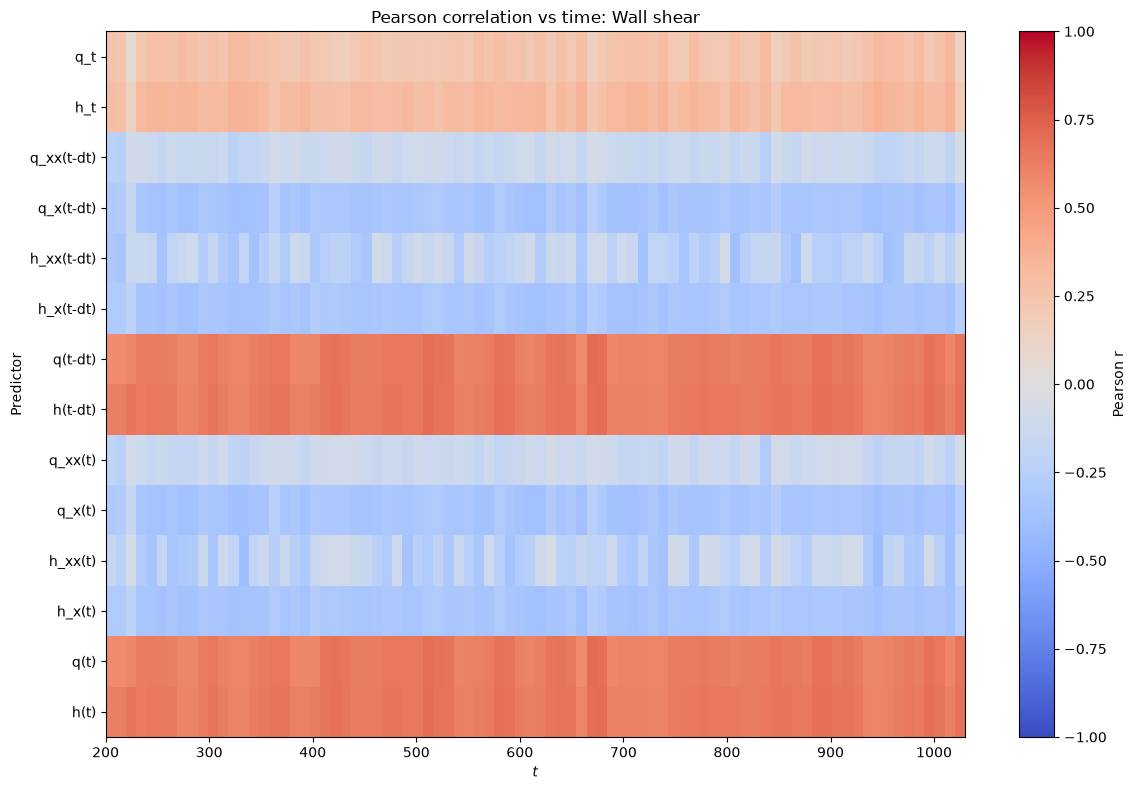

In [17]:
closure_name = "Wall shear"

correlation_vs_time_matrix = np.array([
    time_correlations[
        closure_name
    ][predictor_name]["pearson"]
    for predictor_name in predictors
])


fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(
    correlation_vs_time_matrix,
    aspect="auto",
    origin="lower",
    extent=[
        t[0],
        t[-1],
        -0.5,
        len(predictors) - 0.5,
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_yticks(
    np.arange(len(predictors))
)

ax.set_yticklabels(
    predictors.keys()
)

ax.set_xlabel(r"$t$")
ax.set_ylabel("Predictor")

ax.set_title(
    f"Pearson correlation vs time: {closure_name}"
)

fig.colorbar(
    im,
    ax=ax,
    label="Pearson r",
)

plt.tight_layout()
plt.show()

In [18]:
rows = []

for closure_name in closures:

    for predictor_name in predictors:

        pearson_t = time_correlations[
            closure_name
        ][predictor_name]["pearson"]

        spearman_t = time_correlations[
            closure_name
        ][predictor_name]["spearman"]

        rows.append({
            "Closure": closure_name,
            "Predictor": predictor_name,

            "Pearson mean": np.nanmean(pearson_t),
            "Pearson std": np.nanstd(pearson_t),
            "Pearson min": np.nanmin(pearson_t),
            "Pearson max": np.nanmax(pearson_t),

            "Spearman mean": np.nanmean(spearman_t),
            "Spearman std": np.nanstd(spearman_t),
            "Spearman min": np.nanmin(spearman_t),
            "Spearman max": np.nanmax(spearman_t),
        })


correlation_statistics = pd.DataFrame(rows)

display(correlation_statistics)

,Closure,Predictor,Pearson mean,Pearson std,Pearson min,Pearson max,Spearman mean,Spearman std,Spearman min,Spearman max
0,Shape factor,h(t),0.929762,0.019410,0.877131,0.964091,0.986146,0.003245,0.973274,0.990953
1,Shape factor,q(t),0.979393,0.004153,0.966803,0.986917,0.999352,0.000348,0.996949,0.999628
2,Shape factor,h_x(t),0.020136,0.012887,-0.000443,0.065739,0.235414,0.027362,0.181104,0.298732
3,Shape factor,h_xx(t),-0.098072,0.044919,-0.209081,-0.014269,-0.316498,0.041440,-0.405393,-0.204510
4,Shape factor,q_x(t),0.016727,0.016129,-0.002900,0.103906,0.235493,0.028994,0.178688,0.327922
5,Shape factor,q_xx(t),-0.064798,0.017279,-0.139368,-0.030171,-0.301475,0.043660,-0.386895,-0.186141
6,Shape factor,h(t-dt),0.929777,0.019409,0.877137,0.964101,0.986149,0.003245,0.973286,0.990960
7,Shape factor,q(t-dt),0.979403,0.004153,0.966811,0.986926,0.999313,0.000354,0.996944,0.999622
8,Shape factor,h_x(t-dt),0.019403,0.012912,-0.001191,0.064983,0.234889,0.027307,0.180709,0.298253
9,Shape factor,h_xx(t-dt),-0.099410,0.042148,-0.192202,-0.025251,-0.316258,0.042104,-0.401014,-0.207163


Partial Correlations

In [19]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression


def partial_correlation(
    x_data,
    y_data,
    controls,
):
    """
    Calculate the partial Pearson correlation between x and y
    after removing the linear effects of one or more control
    variables.

    Parameters
    ----------
    x_data : ndarray
        First variable.

    y_data : ndarray
        Second variable.

    controls : ndarray or list of ndarrays
        Variables whose effects should be removed.

    Returns
    -------
    r_partial : float
        Partial Pearson correlation coefficient.
    """

    x_data = np.asarray(x_data, dtype=float).ravel()
    y_data = np.asarray(y_data, dtype=float).ravel()

    # --------------------------------------------------------
    # Construct control matrix
    # --------------------------------------------------------

    if isinstance(controls, (list, tuple)):

        controls = np.column_stack([
            np.asarray(control, dtype=float).ravel()
            for control in controls
        ])

    else:

        controls = np.asarray(controls, dtype=float)

        if controls.ndim == 1:
            controls = controls.reshape(-1, 1)

        elif controls.ndim > 2:
            raise ValueError(
                "controls must be one-dimensional or two-dimensional."
            )

    # --------------------------------------------------------
    # Check dimensions
    # --------------------------------------------------------

    if (
        x_data.size != y_data.size
        or x_data.size != controls.shape[0]
    ):
        raise ValueError(
            "x_data, y_data, and controls must contain "
            "the same number of samples."
        )

    # --------------------------------------------------------
    # Remove NaN / inf
    # --------------------------------------------------------

    valid = (
        np.isfinite(x_data)
        & np.isfinite(y_data)
        & np.all(np.isfinite(controls), axis=1)
    )

    x_valid = x_data[valid]
    y_valid = y_data[valid]
    controls_valid = controls[valid, :]

    if x_valid.size < 3:
        return np.nan

    # --------------------------------------------------------
    # Regress controls out of X
    # --------------------------------------------------------

    model_x = LinearRegression()

    model_x.fit(
        controls_valid,
        x_valid,
    )

    x_residual = (
        x_valid
        - model_x.predict(controls_valid)
    )

    # --------------------------------------------------------
    # Regress controls out of Y
    # --------------------------------------------------------

    model_y = LinearRegression()

    model_y.fit(
        controls_valid,
        y_valid,
    )

    y_residual = (
        y_valid
        - model_y.predict(controls_valid)
    )

    # --------------------------------------------------------
    # Correlate residuals
    # --------------------------------------------------------

    if (
        np.std(x_residual) == 0.0
        or np.std(y_residual) == 0.0
    ):
        return np.nan

    return pearsonr(
        x_residual,
        y_residual,
    ).statistic

In [20]:
r = partial_correlation(
    h,
    tau_w,
    controls=[
        q,
        h_x,
        h_xx,
    ],
)

print(
    f"Partial correlation = {r:.4f}"
)

Partial correlation = 0.2474


Uniqueness of closure term given local data

In [21]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [22]:
def closure_uniqueness(
    predictors,
    closure,
    n_neighbors=10,
):
    """
    Test whether a closure quantity is approximately uniquely
    determined by a set of predictor/state variables.

    Parameters
    ----------
    predictors : list of ndarray
        State variables such as [h, q] or [h, q, h_x].
        Each array must have the same shape.

    closure : ndarray
        Closure quantity such as tau_w or phi_sf.

    n_neighbors : int
        Number of nearest states used to estimate local closure spread.

    Returns
    -------
    results : dict
        Contains local closure standard deviation, normalized
        local standard deviation, local closure range, and
        state-space neighbor distance.
    """

    # --------------------------------------------------------
    # Flatten predictors and closure
    # --------------------------------------------------------

    predictors_flat = [
        np.asarray(variable, dtype=float).ravel()
        for variable in predictors
    ]

    closure_flat = np.asarray(
        closure,
        dtype=float,
    ).ravel()

    # --------------------------------------------------------
    # Remove NaN / inf samples
    # --------------------------------------------------------

    valid = np.isfinite(closure_flat)

    for variable in predictors_flat:
        valid &= np.isfinite(variable)

    X = np.column_stack([
        variable[valid]
        for variable in predictors_flat
    ])

    y = closure_flat[valid]

    # --------------------------------------------------------
    # Standardize state variables
    #
    # Important because h, q, h_x, etc. may have very
    # different numerical scales.
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # --------------------------------------------------------
    # Find nearest states
    #
    # +1 because every point is its own closest neighbor.
    # --------------------------------------------------------

    model = NearestNeighbors(
        n_neighbors=n_neighbors + 1,
    )

    model.fit(X_scaled)

    distances, indices = model.kneighbors(
        X_scaled
    )

    # Remove the point itself
    distances = distances[:, 1:]
    indices = indices[:, 1:]

    # --------------------------------------------------------
    # Closure values of neighboring states
    # --------------------------------------------------------

    neighbor_closure = y[indices]

    # Local variation of closure
    closure_std = np.std(
        neighbor_closure,
        axis=1,
    )

    closure_range = (
        np.max(neighbor_closure, axis=1)
        - np.min(neighbor_closure, axis=1)
    )

    # Typical state-space distance to neighbors
    state_distance = np.mean(
        distances,
        axis=1,
    )

    # --------------------------------------------------------
    # Normalize closure spread by total closure variation
    # --------------------------------------------------------

    global_closure_std = np.std(y)

    normalized_closure_std = (
        closure_std / global_closure_std
    )

    return {
        "state": X,
        "closure": y,
        "neighbor_indices": indices,
        "state_distance": state_distance,
        "closure_std": closure_std,
        "closure_range": closure_range,
        "normalized_closure_std": normalized_closure_std,
        "global_closure_std": global_closure_std,
    }

In [23]:
result_hq = closure_uniqueness(predictors=[h,q,],
    closure=tau_w, n_neighbors=10,)

print("Mean normalized local std:", np.mean(result_hq["normalized_closure_std"]),)

print("Median normalized local std:", np.median(result_hq["normalized_closure_std"]),)

print("90th percentile:", np.percentile(result_hq["normalized_closure_std"], 90,),)

Mean normalized local std: 0.2390274512307898
Median normalized local std: 0.15051602138381767
90th percentile: 0.5812197666918468


In [24]:
state_tests = {
    "h": [
        h,
    ],

    "q": [
        q,
    ],

    "h, q": [
        h,
        q,
    ],

    "h, q, h_x": [
        h,
        q,
        h_x,
    ],

    "h, q, h_x, h_xx": [
        h,
        q,
        h_x,
        h_xx,
    ],

    "h, q, h_x, h_xx, q_x": [
        h,
        q,
        h_x,
        h_xx,
        q_x,
    ],

    "h, q, h_x, h_xx, q_x, q_xx": [
        h,
        q,
        h_x,
        h_xx,
        q_x,
        q_xx,
    ],
}

In [27]:
rows = []
tau_w_diff = tau_w - (3 * q / h**2)
for state_name, state_variables in state_tests.items():

    result = closure_uniqueness(
        predictors=state_variables,
        closure=tau_w_diff,
        n_neighbors=10,
    )

    normalized_std = (
        result["normalized_closure_std"]
    )

    rows.append({
        "State variables": state_name,
        "Mean local std": np.mean(
            normalized_std
        ),
        "Median local std": np.median(
            normalized_std
        ),
        "90th percentile": np.percentile(
            normalized_std,
            90,
        ),
        "Mean state distance": np.mean(
            result["state_distance"]
        ),
    })

tau_uniqueness_table = pd.DataFrame(
    rows
)

display(tau_uniqueness_table)

,State variables,Mean local std,Median local std,90th percentile,Mean state distance
0,h,0.664800,0.484015,1.426906,0.000020
1,q,0.652150,0.476551,1.397154,0.000036
2,"h, q",0.560984,0.353348,1.365014,0.001601
3,"h, q, h_x",0.086276,0.034427,0.222272,0.012307
4,"h, q, h_x, h_xx",0.062208,0.019432,0.158194,0.023909
5,"h, q, h_x, h_xx, q_x",0.038528,0.013647,0.092207,0.032483
6,"h, q, h_x, h_xx, q_x, q_xx",0.037848,0.013698,0.091613,0.046295


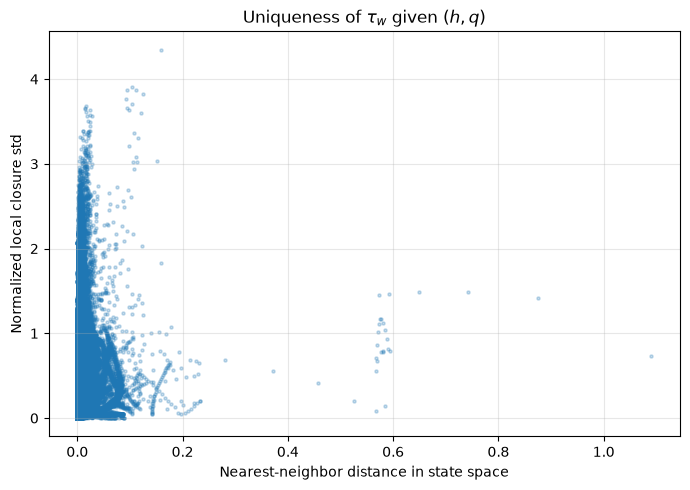

In [26]:
result = closure_uniqueness(
    predictors=[
        h,
        q,
    ],
    closure=tau_w,
    n_neighbors=10,
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    result["state_distance"],
    result["normalized_closure_std"],
    s=5,
    alpha=0.25,
)

ax.set_xlabel(
    "Nearest-neighbor distance in state space"
)

ax.set_ylabel(
    "Normalized local closure std"
)

ax.set_title(
    r"Uniqueness of $\tau_w$ given $(h,q)$"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()